# Visualize fire risk maps from raster data

In [1]:
from src.config import FIRERISK_MAPS_DIR, FIGURES_DIR

2025-07-04 11:47:47.319 | INFO     | src.config:<module>:13 - PROJ_ROOT path is: C:\Workspace\Projects\GAIA\Repos\IberFire


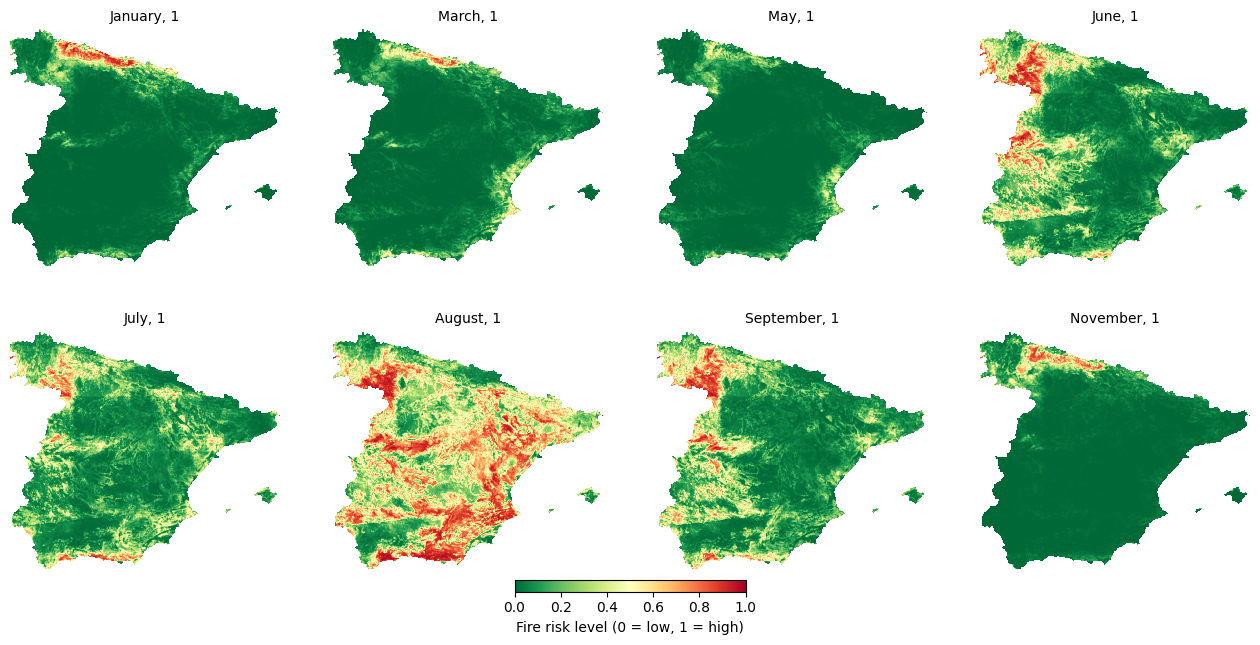

In [2]:
import rasterio
import matplotlib.pyplot as plt
from datetime import datetime

paths = []
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-01-01.tif")
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-03-01.tif")
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-05-01.tif")
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-06-01.tif")
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-07-01.tif")
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-08-01.tif")
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-09-01.tif")
paths.append(FIRERISK_MAPS_DIR / "Riskmap_2024-11-01.tif")

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
axes = axes.flatten()

for i, path in enumerate(paths):
    with rasterio.open(path) as src:
        raster = src.read(1)
        raster = raster[30:900, 100:1090]
    
    filename = path.stem  
    date_str = filename.split("_")[1]  
    month_name = datetime.strptime(date_str, "%Y-%m-%d").strftime("%B") 

    ax = axes[i]
    im = ax.imshow(raster, cmap="RdYlGn_r", vmin=0, vmax=1)
    ax.set_title(month_name + ", 1", fontsize = 10)
    ax.axis('off')

cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.02, pad=0.02)
cbar.set_label('Fire risk level (0 = low, 1 = high)')
plt.savefig(FIGURES_DIR / "firerisks.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.savefig(FIGURES_DIR / "firerisks.png", dpi=300, bbox_inches="tight", format="png")